### 라이브러리 임포트

In [28]:
# --------------------------------------------------
# [1] 라이브러리 임포트 및 시각화 설정 
# --------------------------------------------------
import duckdb
import polars as pl
import pandas as pd
import os
import platform
import matplotlib.pyplot as plt
import seaborn as sns

# Polars, Pandas 출력 옵션 설정
pl.Config.set_tbl_rows(10)
pd.set_option('display.max_columns', 100)

# 🚨 반드시 Seaborn 임포트 이후에 폰트 설정 실행
if platform.system() == 'Darwin':  # Mac 환경
    plt.rc('font', family='Apple SD Gothic Neo')
elif platform.system() == 'Windows':  # Windows 환경
    plt.rc('font', family='Malgun Gothic')
else:  # Linux (Google Colab 등) 환경
    plt.rc('font', family='NanumGothic')

# 마이너스 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

### 데이터 로드

In [29]:
# --------------------------------------------------
# [2] 파일 경로 설정 및 데이터 로드
# --------------------------------------------------
BASE_DIR = os.path.abspath('..')
PARQUET_PATH = os.path.join(BASE_DIR, 'data', 'processed', 'sdot_final_mapped.parquet')

print(f"데이터 경로: {PARQUET_PATH}")
print(f"파일 존재 여부: {os.path.exists(PARQUET_PATH)}\n")

# DuckDB에 Parquet 파일을 뷰(v_sdot)로 즉시 등록
# -> 메모리를 적게 차지하며, 이후 SQL 쿼리에서 'v_sdot' 테이블명으로 바로 호출 가능
duckdb.sql(f"CREATE OR REPLACE VIEW v_sdot AS SELECT * FROM read_parquet('{PARQUET_PATH}')")

# --------------------------------------------------
# [3] 데이터 정상 로드 확인
# --------------------------------------------------
query_check = """
    SELECT * 
    FROM v_sdot
    LIMIT 5
"""
print("📌 [데이터 미리보기]")
display(duckdb.sql(query_check).pl())

데이터 경로: /Users/gomdori/Documents/Git/sdot-analysis/data/processed/sdot_final_mapped.parquet
파일 존재 여부: True

📌 [데이터 미리보기]


measure_time,sensor_id,temp_max,temp_avg,temp_min,humi_max,humi_avg,humi_min,wind_spd_max,wind_spd_avg,wind_spd_min,wind_dir_max,wind_dir_avg,wind_dir_min,illu_max,illu_avg,illu_min,uv_max,uv_avg,uv_min,noise_max,noise_avg,noise_min,vibe_x_max_g,vibe_x_avg_g,vibe_x_min_g,vibe_y_max_g,vibe_y_avg_g,vibe_y_min_g,vibe_z_max_g,vibe_z_avg_g,vibe_z_min_g,vibe_x_max_mms,vibe_x_avg_mms,vibe_x_min_mms,vibe_y_max_mms,vibe_y_avg_mms,…,flag_vibe_x_avg_mms,flag_vibe_x_min_mms,flag_vibe_y_max_mms,flag_vibe_y_avg_mms,flag_vibe_y_min_mms,flag_vibe_z_max_mms,flag_vibe_z_avg_mms,flag_vibe_z_min_mms,flag_wbgt_max,flag_wbgt_avg,flag_wbgt_min,flag_no2_max,flag_no2_avg,flag_no2_min,flag_co_max,flag_co_avg,flag_co_min,flag_so2_max,flag_so2_avg,flag_so2_min,flag_nh3_max,flag_nh3_avg,flag_nh3_min,flag_h2s_max,flag_h2s_avg,flag_h2s_min,flag_o3_max,flag_o3_avg,flag_o3_min,flag_pm10,flag_pm25,measure_timestamp,sensor_id_matched,lat,lon,address,district
str,str,str,f64,str,str,f64,str,f64,f64,str,f64,f64,str,str,f64,str,str,f64,str,str,f64,str,f64,f64,str,f64,f64,str,f64,f64,str,str,str,str,str,str,…,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,datetime[μs],str,f64,f64,str,str
"""2020.4.4 10:00""","""V02Q1940078""",null,13.2,null,null,2.0,null,0.0,0.0,null,0.0,0.0,null,null,28128.0,null,null,2.0,null,null,null,null,0.06,0.01,null,0.11,0.05,null,1.14,1.06,null,null,null,null,null,null,…,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,2020-04-04 10:00:00,"""V02Q1940078""",37.542549,126.840313,"""서울특별시 강서구 화곡로27길 16""","""강서구"""
"""2020.4.4 16:00""","""V02Q1940078""",null,15.0,null,null,null,null,0.0,0.0,null,0.0,0.0,null,null,9479.0,null,null,1.0,null,null,null,null,0.07,0.02,null,0.11,0.05,null,1.12,1.05,null,null,null,null,null,null,…,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,2020-04-04 16:00:00,"""V02Q1940078""",37.542549,126.840313,"""서울특별시 강서구 화곡로27길 16""","""강서구"""
"""2020.4.4 22:00""","""V02Q1940078""",null,9.2,null,null,2.0,null,0.0,0.0,null,0.0,0.0,null,null,30.0,null,null,0.0,null,null,null,null,0.06,0.01,null,0.1,0.05,null,1.14,1.07,null,null,null,null,null,null,…,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,2020-04-04 22:00:00,"""V02Q1940078""",37.542549,126.840313,"""서울특별시 강서구 화곡로27길 16""","""강서구"""
"""2020.4.5 4:00""","""V02Q1940078""",null,6.3,null,null,2.0,null,0.0,0.0,null,0.0,0.0,null,null,26.0,null,null,0.0,null,null,null,null,0.06,0.01,null,0.11,0.04,null,1.15,1.07,null,null,null,null,null,null,…,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,2020-04-05 04:00:00,"""V02Q1940078""",37.542549,126.840313,"""서울특별시 강서구 화곡로27길 16""","""강서구"""
"""2020.4.5 10:00""","""V02Q1940078""",null,9.0,null,null,1.0,null,0.0,0.0,null,0.0,0.0,null,null,30247.0,null,null,2.0,null,null,null,null,0.06,0.01,null,0.11,0.05,null,1.14,1.06,null,null,null,null,null,null,…,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,2020-04-05 10:00:00,"""V02Q1940078""",37.542549,126.840313,"""서울특별시 강서구 화곡로27길 16""","""강서구"""


# 위치미상(메타데이터 누락 의심) 센서 ID 확인

In [19]:
import pandas as pd

# 1. DuckDB 뷰에서 위치미상 센서 ID 추출
query_missing_meta = """
    SELECT DISTINCT sensor_id_matched
    FROM v_sdot
    WHERE district = '위치미상'
"""
df_missing_meta = duckdb.sql(query_missing_meta).pl().to_pandas()
missing_sensors = df_missing_meta['sensor_id_matched'].dropna().tolist()

# 2. 메타데이터 엑셀 파일 로드 (이전 노트북 환경의 경로 참고)
meta_filepath = '../metadata/서울시 도시데이터 센서(S-DoT) 환경정보 설치 위치정보.xlsx'
try:
    # 이미 로드된 loc_df가 있다면 활용하고, 없다면 새로 읽어옵니다.
    meta_df = loc_df.copy()
except NameError:
    meta_df = pd.read_excel(meta_filepath)
    meta_df = meta_df.rename(columns={'모델 시리얼(*)': '시리얼'})

# 3. 메타데이터의 시리얼 관련 모든 컬럼 값 추출하여 하나의 집합(Set)으로 만들기
all_meta_serials = set()
for col in ['시리얼', '변경 전 시리얼', '변경 전 시리얼(데이터 상 표기)']:
    if col in meta_df.columns:
        # 결측치를 제외하고 문자열로 변환하여 세트에 추가
        all_meta_serials.update(meta_df[col].dropna().astype(str).str.strip().tolist())

# 4. 교차 검증: 위치미상 센서들이 메타데이터 시리얼 집합에 포함되는지 확인
really_missing = []
found_in_meta = []

for sid in missing_sensors:
    if sid in all_meta_serials:
        found_in_meta.append(sid)
    else:
        really_missing.append(sid)
        
print(f"🔍 검증 대상 '위치미상' 센서 개수: {len(missing_sensors)}개")
print("-" * 50)

if found_in_meta:
    print(f"⚠️ 앗! 메타데이터 엑셀에 존재하는데 매핑 과정에서 누락된 센서가 {len(found_in_meta)}개 있습니다.")
    print(f"👉 누락된 센서 리스트: {found_in_meta}")
    print("매핑 로직이나 문자열 공백 등의 문제를 다시 점검해야 합니다.")
else:
    print(f"✅ 검증 완료: 20개의 센서 모두 메타데이터 엑셀 파일 어디에도 존재하지 않습니다!")
    print(f"❌ (진짜로 메타데이터에 없는 센서: {len(really_missing)}개)")

🔍 검증 대상 '위치미상' 센서 개수: 20개
--------------------------------------------------
✅ 검증 완료: 20개의 센서 모두 메타데이터 엑셀 파일 어디에도 존재하지 않습니다!
❌ (진짜로 메타데이터에 없는 센서: 20개)


In [18]:
query_missing_meta = """
    SELECT 
        sensor_id_matched,
        MIN(measure_timestamp) AS 최초_수집일,
        MAX(measure_timestamp) AS 최종_수집일
    FROM v_sdot
    WHERE district = '위치미상'
    GROUP BY sensor_id_matched
    ORDER BY 최종_수집일 DESC
"""
df_missing_meta = duckdb.sql(query_missing_meta).pl().to_pandas()

print(f"🚨 메타데이터 파일에 없는 것으로 추정되는 센서: {len(df_missing_meta)}개")
display(df_missing_meta)

🚨 메타데이터 파일에 없는 것으로 추정되는 센서: 20개


,sensor_id_matched,최초_수집일,최종_수집일
0,OC3CL200808,2025-10-06 00:07:00,2025-10-13 12:07:00
1,OC3CL200805,2025-10-06 00:07:00,2025-10-13 12:07:00
2,OC3CL200810,2025-10-06 00:07:00,2025-10-13 12:07:00
3,OC3CL200806,2025-10-06 00:07:00,2025-10-13 12:07:00
4,OC3CL200801,2025-10-06 00:07:00,2025-10-13 12:07:00
5,OC3CL200809,2025-10-06 00:07:00,2025-10-13 12:07:00
6,OC3CL200803,2025-10-06 00:07:00,2025-10-13 12:07:00
7,OC3CL200802,2025-10-06 00:07:00,2025-10-13 12:07:00
8,OC3CL200807,2025-10-06 00:07:00,2025-10-13 12:07:00
9,OC3CL200804,2025-10-06 00:07:00,2025-10-13 12:07:00


# [0] 기상 및 환경 지표 결측치 비율 분석

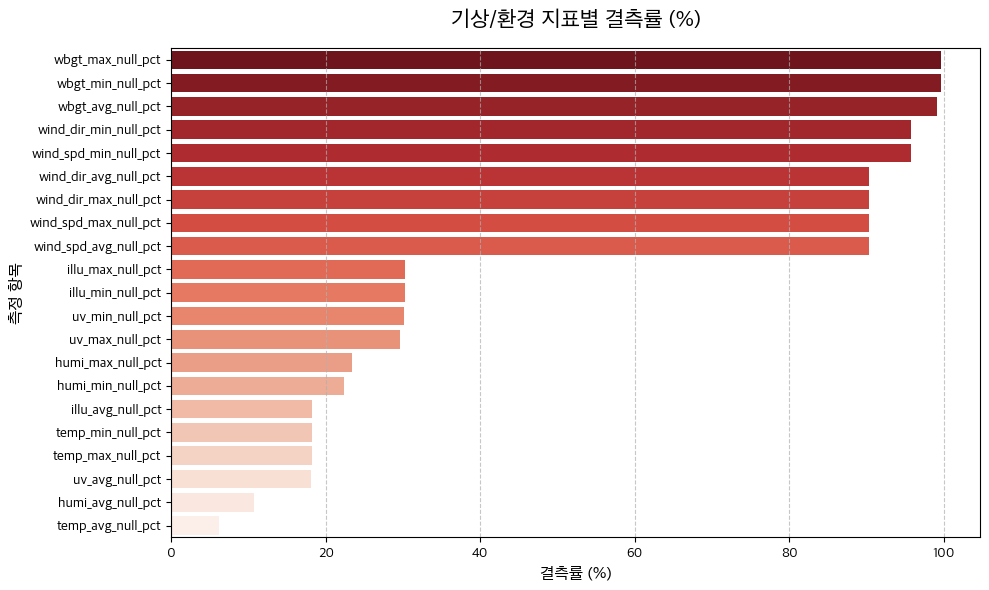

In [11]:
# 분석 대상 기상 컬럼
climate_cols = ['temp_min','temp_avg', 'temp_max',
                'humi_min','humi_avg', 'humi_max',
                'wind_spd_min','wind_spd_avg', 'wind_spd_max',
                'wind_dir_min','wind_dir_avg', 'wind_dir_max',
                'illu_min','illu_avg', 'illu_max',
                'uv_min','uv_avg', 'uv_max',
                'wbgt_min','wbgt_avg', 'wbgt_max']

# DuckDB를 이용해 각 컬럼별 NULL 카운트 및 총 행 수 계산
null_queries = []
for col in climate_cols:
    null_queries.append(f"SUM(CASE WHEN {col} IS NULL THEN 1 ELSE 0 END) * 100.0 / COUNT(*) AS {col}_null_pct")

query_missing = f"SELECT {', '.join(null_queries)} FROM v_sdot"
df_missing = duckdb.sql(query_missing).pl().to_pandas().T
df_missing.columns = ['결측률(%)']
df_missing = df_missing.sort_values(by='결측률(%)', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=df_missing['결측률(%)'], y=df_missing.index, hue=df_missing.index, palette='Reds_r', legend=False)

plt.title("기상/환경 지표별 결측률 (%)", fontsize=16, pad=15)
plt.xlabel("결측률 (%)", fontsize=12)
plt.ylabel("측정 항목", fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# [1] 일교차 패턴 분석 (월별 평균 최고/최저 기온 및 일교차)

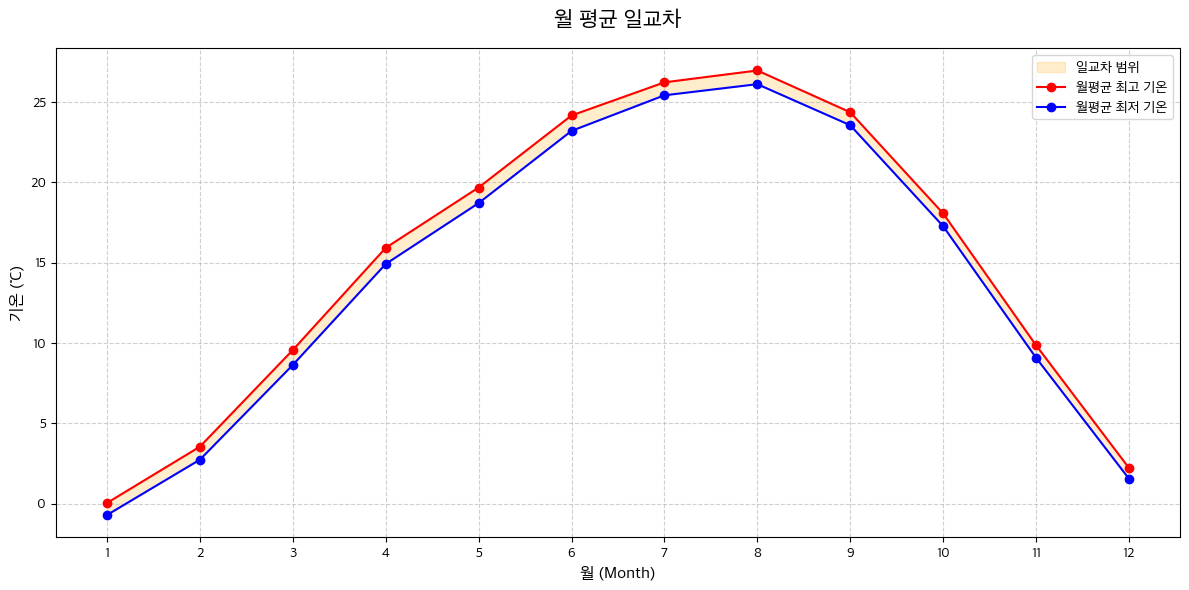

In [8]:
query_temp = """
    SELECT 
        EXTRACT(month FROM measure_timestamp) AS month,
        AVG(TRY_CAST(temp_max AS DOUBLE)) AS avg_max_temp,
        AVG(TRY_CAST(temp_min AS DOUBLE)) AS avg_min_temp,
        AVG(TRY_CAST(temp_max AS DOUBLE) - TRY_CAST(temp_min AS DOUBLE)) AS avg_diurnal_range
    FROM v_sdot
    WHERE temp_max IS NOT NULL AND temp_min IS NOT NULL
    GROUP BY month
    ORDER BY month
"""
df_temp = duckdb.sql(query_temp).pl().to_pandas()

plt.figure(figsize=(12, 6))
# 최고/최저 기온 영역 채우기
plt.fill_between(df_temp['month'], df_temp['avg_min_temp'], df_temp['avg_max_temp'], color='orange', alpha=0.2, label='일교차 범위')
plt.plot(df_temp['month'], df_temp['avg_max_temp'], marker='o', color='red', label='월평균 최고 기온')
plt.plot(df_temp['month'], df_temp['avg_min_temp'], marker='o', color='blue', label='월평균 최저 기온')

plt.title("월 평균 일교차", fontsize=16, pad=15)
plt.xlabel("월 (Month)", fontsize=12)
plt.ylabel("기온 (℃)", fontsize=12)
plt.xticks(range(1, 13))
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# [2] 월별 조도 및 자외선 변화

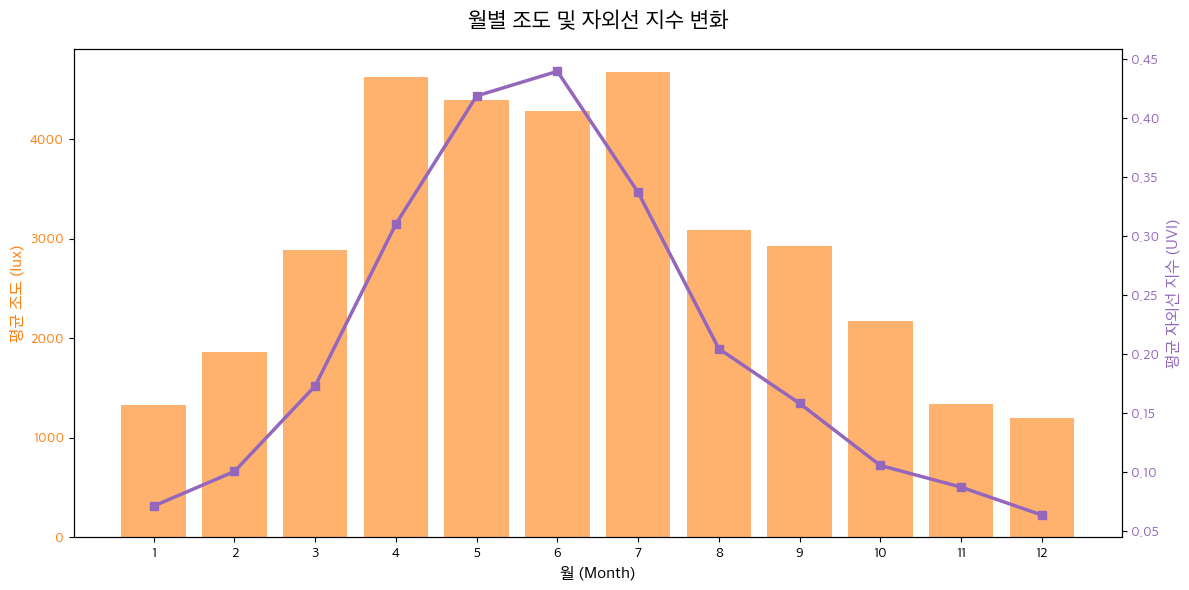

In [6]:
query_illu_uv = """
    SELECT 
        EXTRACT(month FROM measure_timestamp) AS month,
        AVG(illu_avg) AS avg_illu,
        AVG(uv_avg) AS avg_uv
    FROM v_sdot
    WHERE illu_avg IS NOT NULL AND uv_avg IS NOT NULL
    GROUP BY month
    ORDER BY month
"""
df_illu_uv = duckdb.sql(query_illu_uv).pl().to_pandas()

fig, ax1 = plt.subplots(figsize=(12, 6))

# 조도 시각화 (왼쪽 Y축)
color1 = 'tab:orange'
ax1.set_xlabel('월 (Month)', fontsize=12)
ax1.set_ylabel('평균 조도 (lux)', color=color1, fontsize=12)
ax1.bar(df_illu_uv['month'], df_illu_uv['avg_illu'], color=color1, alpha=0.6, label='조도')
ax1.tick_params(axis='y', labelcolor=color1)
ax1.set_xticks(range(1, 13))

# 자외선 시각화 (오른쪽 Y축)
ax2 = ax1.twinx()  
color2 = 'tab:purple'
ax2.set_ylabel('평균 자외선 지수 (UVI)', color=color2, fontsize=12)
ax2.plot(df_illu_uv['month'], df_illu_uv['avg_uv'], color=color2, marker='s', linewidth=2.5, label='자외선')
ax2.tick_params(axis='y', labelcolor=color2)

plt.title("월별 조도 및 자외선 지수 변화", fontsize=16, pad=15)
fig.tight_layout()
plt.show()

# [3] 자치구별 평균 풍속 및 돌풍(최대-평균) 강도 분석

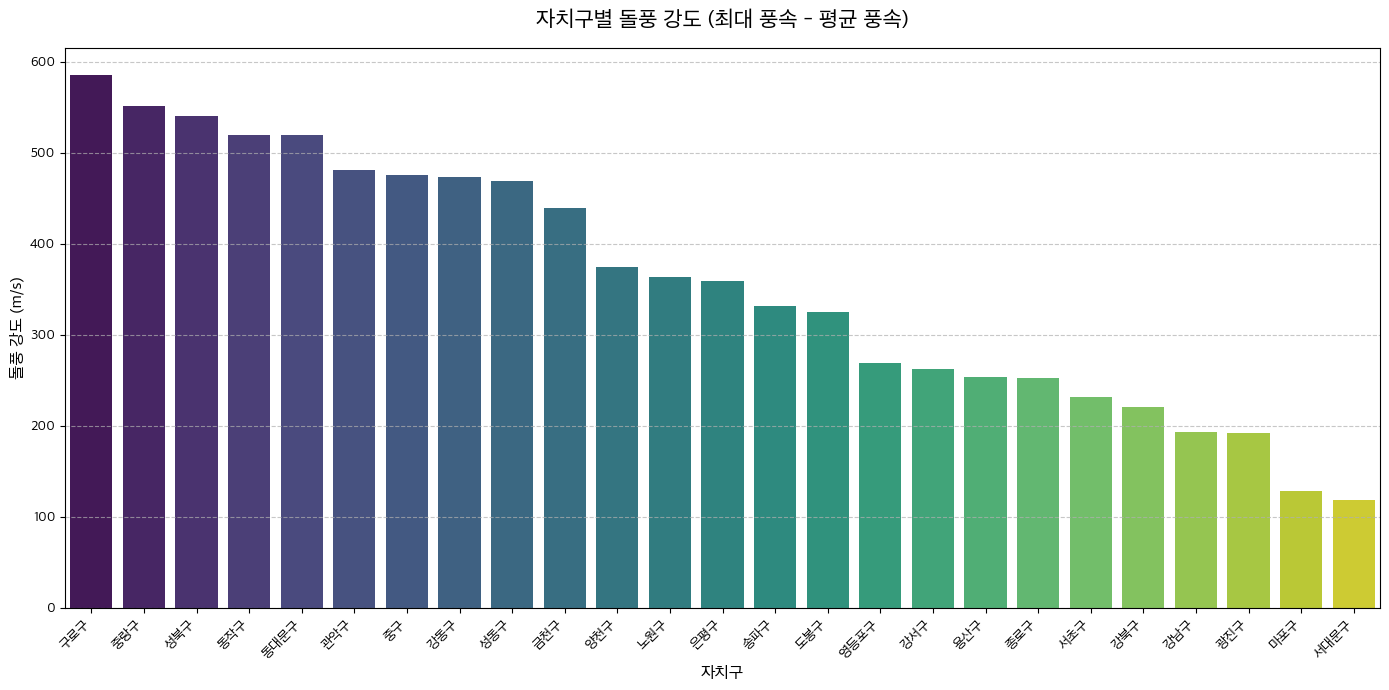

In [9]:
query_wind = """
    SELECT 
        district AS 자치구,
        AVG(wind_spd_avg) AS 평균_풍속,
        AVG(wind_spd_max - wind_spd_avg) AS 돌풍_강도
    FROM v_sdot
    WHERE district != '위치미상' AND wind_spd_avg IS NOT NULL AND wind_spd_max IS NOT NULL
    GROUP BY district
    ORDER BY 돌풍_강도 DESC
"""
df_wind = duckdb.sql(query_wind).pl().to_pandas()

plt.figure(figsize=(14, 7))
# Seaborn barplot 사용 시 x를 hue로 지정하여 경고 방지
sns.barplot(data=df_wind, x='자치구', y='돌풍_강도', hue='자치구', palette='viridis', legend=False)

plt.title("자치구별 돌풍 강도 (최대 풍속 - 평균 풍속)", fontsize=16, pad=15)
plt.xlabel("자치구", fontsize=12)
plt.ylabel("돌풍 강도 (m/s)", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# [4] 기상 지표 수집 간격(분) 분포 분석

In [21]:
climate_cols = ['temp_min','temp_avg', 'temp_max',
                'humi_min','humi_avg', 'humi_max',
                'wind_spd_min','wind_spd_avg', 'wind_spd_max',
                'wind_dir_min','wind_dir_avg', 'wind_dir_max',
                'illu_min','illu_avg', 'illu_max',
                'uv_min','uv_avg', 'uv_max',
                'wbgt_min','wbgt_avg', 'wbgt_max']

# 1. SELECT 절에서 모든 대상 컬럼을 명시적으로 DOUBLE형으로 캐스팅
casted_cols = [f"TRY_CAST({col} AS DOUBLE) AS {col}" for col in climate_cols]
climate_cols_cast_str = ", ".join(casted_cols)

# 2. UNPIVOT ON 절에는 컬럼 이름만 필요
climate_cols_str = ", ".join(climate_cols) 

query_interval = f"""
    WITH gap_calc AS (
        SELECT 
            sensor_id_matched,
            measure_timestamp,
            DATE_DIFF('minute', 
                      LAG(measure_timestamp) OVER(PARTITION BY sensor_id_matched ORDER BY measure_timestamp), 
                      measure_timestamp) AS time_gap_minutes,
            {climate_cols_cast_str}
        FROM v_sdot
    ),
    unpivoted_gaps AS (
        UNPIVOT gap_calc
        ON {climate_cols_str}
        INTO
            NAME measure_type
            VALUE measure_value
    )
    SELECT 
        measure_type AS 측정_항목,
        MEDIAN(time_gap_minutes) AS 중앙값_간격_분,
        ROUND(AVG(time_gap_minutes), 1) AS 평균_간격_분
    FROM unpivoted_gaps
    WHERE measure_value IS NOT NULL
      AND time_gap_minutes > 0  
    GROUP BY measure_type
    ORDER BY 중앙값_간격_분 ASC, 측정_항목 ASC
"""
df_interval = duckdb.sql(query_interval).pl().to_pandas()

print("📌 [기상 지표별 실제 측정 주기]")
display(df_interval)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

📌 [기상 지표별 실제 측정 주기]


,측정_항목,중앙값_간격_분,평균_간격_분
0,humi_avg,60.0,121.9
1,humi_max,60.0,132.7
2,humi_min,60.0,131.8
3,illu_avg,60.0,120.8
4,illu_max,60.0,131.8
5,illu_min,60.0,131.8
6,temp_avg,60.0,119.1
7,temp_max,60.0,128.3
8,temp_min,60.0,128.3
9,uv_avg,60.0,120.8


In [23]:
climate_cols = ['temp_min','temp_avg', 'temp_max',
                'humi_min','humi_avg', 'humi_max',
                'wind_spd_min','wind_spd_avg', 'wind_spd_max',
                'wind_dir_min','wind_dir_avg', 'wind_dir_max',
                'illu_min','illu_avg', 'illu_max',
                'uv_min','uv_avg', 'uv_max',
                'wbgt_min','wbgt_avg', 'wbgt_max']

# 1. SELECT 절에서 모든 대상 컬럼을 명시적으로 DOUBLE형으로 캐스팅
casted_cols = [f"TRY_CAST({col} AS DOUBLE) AS {col}" for col in climate_cols]
climate_cols_cast_str = ", ".join(casted_cols)

# 2. UNPIVOT ON 절에는 컬럼 이름만 필요
climate_cols_str = ", ".join(climate_cols) 

# 수정된 쿼리: UNPIVOT -> NULL 제거 -> LAG(간격) 계산
query_interval = f"""
    WITH unpivoted_data AS (
        UNPIVOT (
            SELECT 
                sensor_id_matched, 
                measure_timestamp, 
                {climate_cols_cast_str}
            FROM v_sdot
        )
        ON {climate_cols_str}
        INTO
            NAME measure_type
            VALUE measure_value
    ),
    gap_calc AS (
        SELECT 
            measure_type,
            DATE_DIFF('minute', 
                      LAG(measure_timestamp) OVER(PARTITION BY sensor_id_matched, measure_type ORDER BY measure_timestamp), 
                      measure_timestamp) AS time_gap_minutes
        FROM unpivoted_data
        WHERE measure_value IS NOT NULL
    )
    SELECT 
        measure_type AS 측정_항목,
        MEDIAN(time_gap_minutes) AS 중앙값_간격_분,
        ROUND(AVG(time_gap_minutes), 1) AS 평균_간격_분
    FROM gap_calc
    WHERE time_gap_minutes > 0  
    GROUP BY measure_type
    ORDER BY 중앙값_간격_분 ASC, 측정_항목 ASC
"""
df_interval = duckdb.sql(query_interval).pl().to_pandas()

print("📌 [기상 지표별 측정 주기]")
display(df_interval)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

📌 [기상 지표별 측정 주기]


,측정_항목,중앙값_간격_분,평균_간격_분
0,humi_avg,60.0,132.0
1,humi_max,60.0,124.2
2,humi_min,60.0,122.5
3,illu_avg,60.0,121.9
4,illu_max,60.0,110.3
5,illu_min,60.0,110.3
6,temp_avg,60.0,124.9
7,temp_max,60.0,115.6
8,temp_min,60.0,115.6
9,uv_avg,60.0,121.9


# [5] 연도별 월별 결측률 시각화

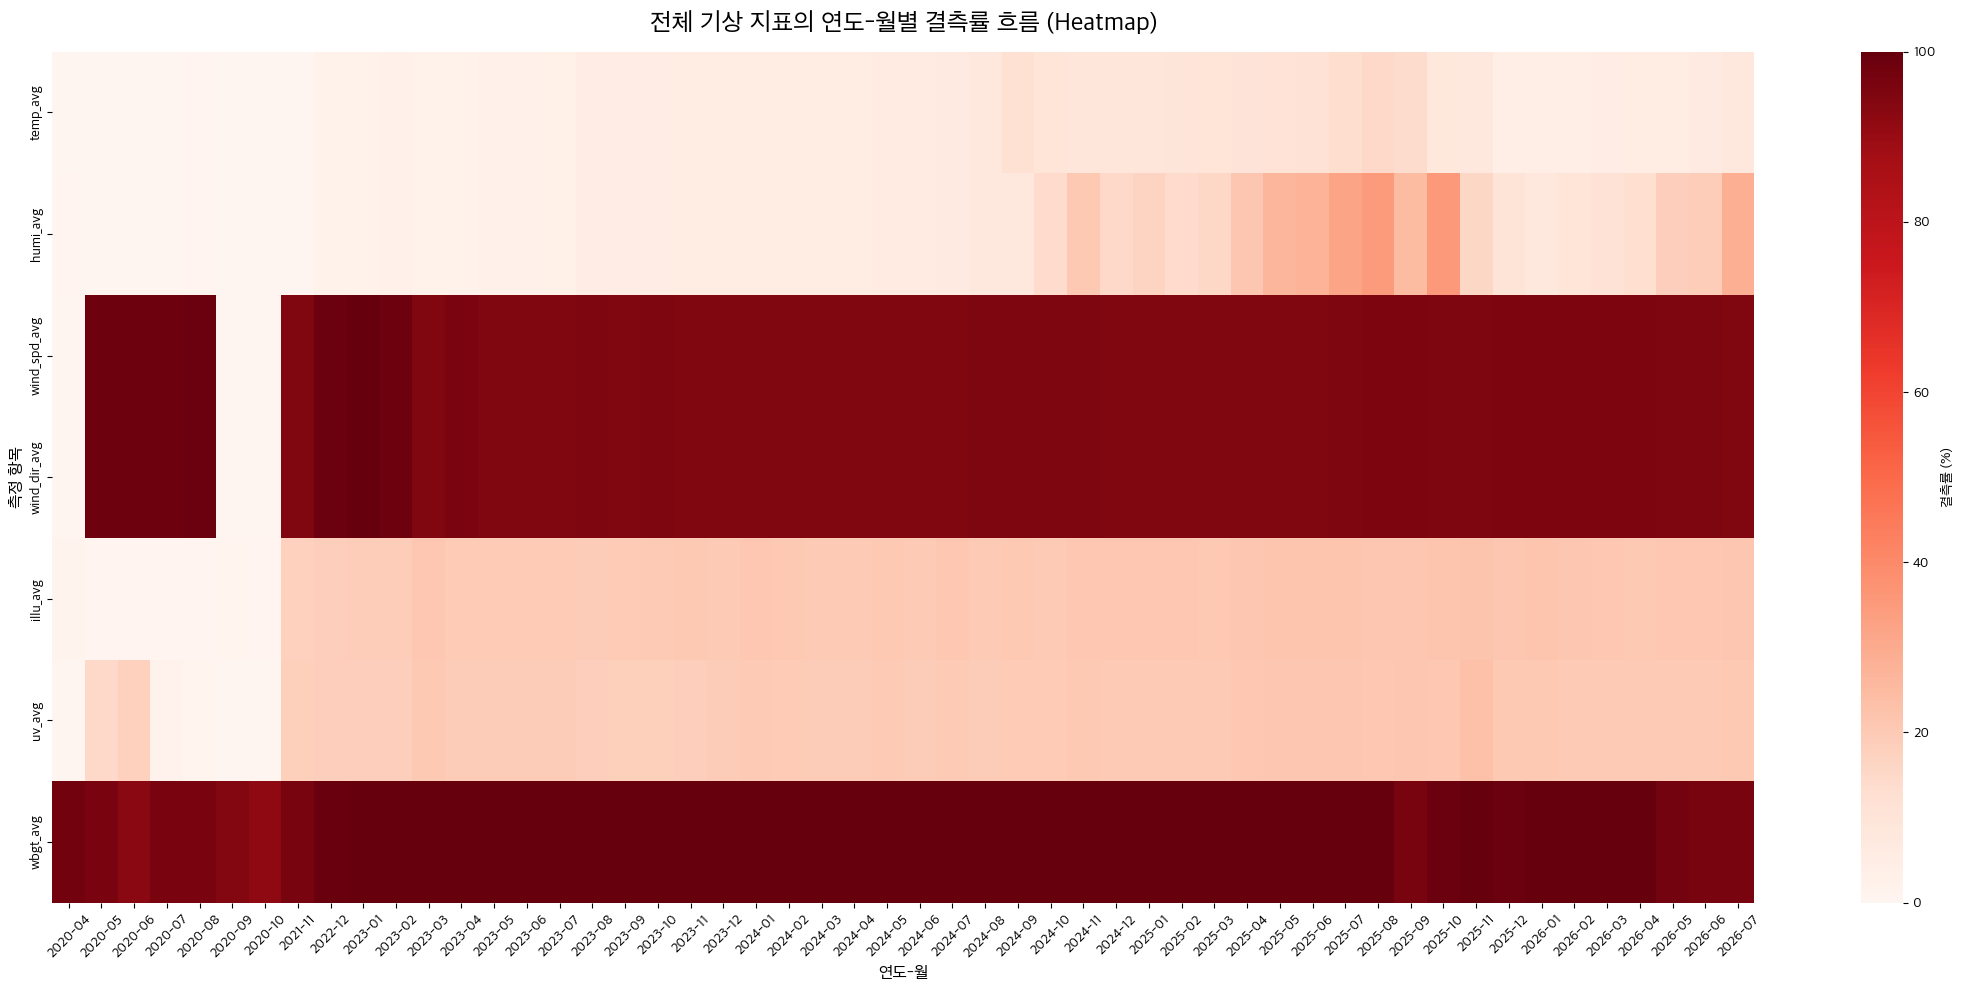

/var/folders/c6/_5q2k4291yj3lw8b4k_0fc8m0000gn/T/ipykernel_59808/1642909351.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=year_data, x='month', y=item_name, palette='coolwarm', ax=ax)
/var/folders/c6/_5q2k4291yj3lw8b4k_0fc8m0000gn/T/ipykernel_59808/1642909351.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=year_data, x='month', y=item_name, palette='coolwarm', ax=ax)
/var/folders/c6/_5q2k4291yj3lw8b4k_0fc8m0000gn/T/ipykernel_59808/1642909351.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=year_data, x='month',

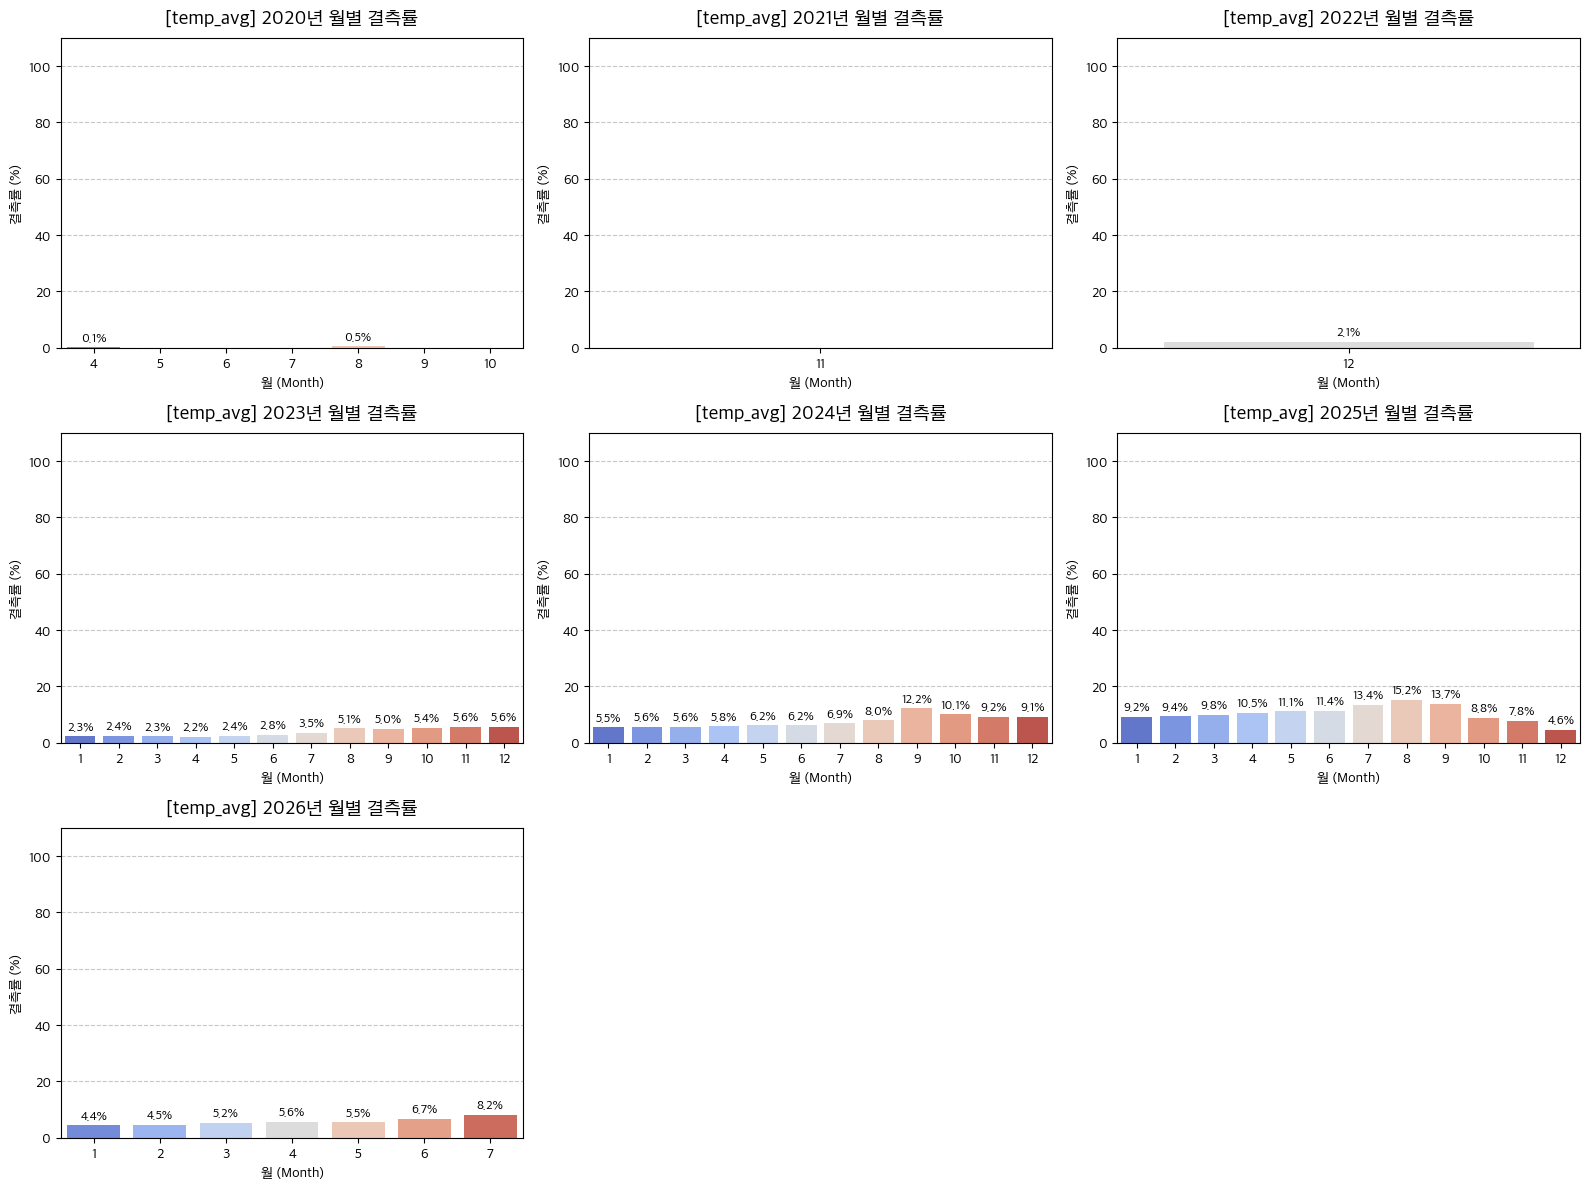

/var/folders/c6/_5q2k4291yj3lw8b4k_0fc8m0000gn/T/ipykernel_59808/1642909351.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=year_data, x='month', y=item_name, palette='coolwarm', ax=ax)
/var/folders/c6/_5q2k4291yj3lw8b4k_0fc8m0000gn/T/ipykernel_59808/1642909351.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=year_data, x='month', y=item_name, palette='coolwarm', ax=ax)
/var/folders/c6/_5q2k4291yj3lw8b4k_0fc8m0000gn/T/ipykernel_59808/1642909351.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=year_data, x='month',

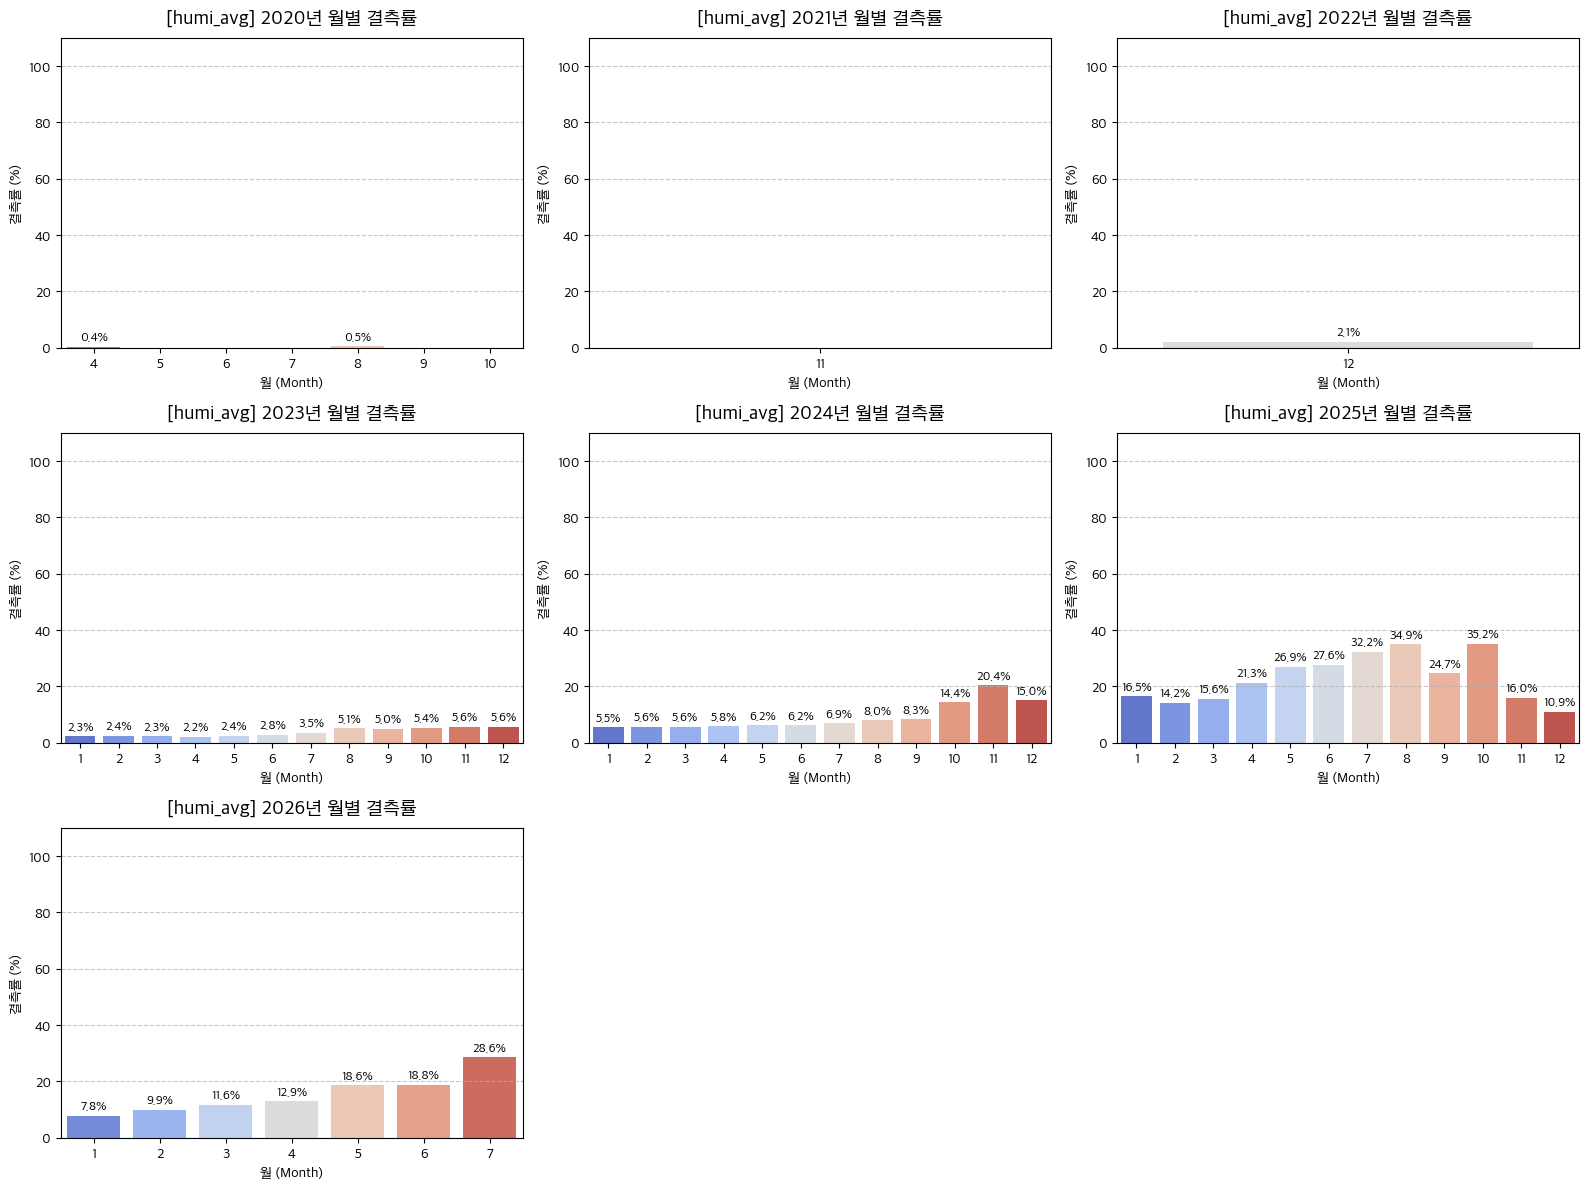

/var/folders/c6/_5q2k4291yj3lw8b4k_0fc8m0000gn/T/ipykernel_59808/1642909351.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=year_data, x='month', y=item_name, palette='coolwarm', ax=ax)
/var/folders/c6/_5q2k4291yj3lw8b4k_0fc8m0000gn/T/ipykernel_59808/1642909351.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=year_data, x='month', y=item_name, palette='coolwarm', ax=ax)
/var/folders/c6/_5q2k4291yj3lw8b4k_0fc8m0000gn/T/ipykernel_59808/1642909351.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=year_data, x='month',

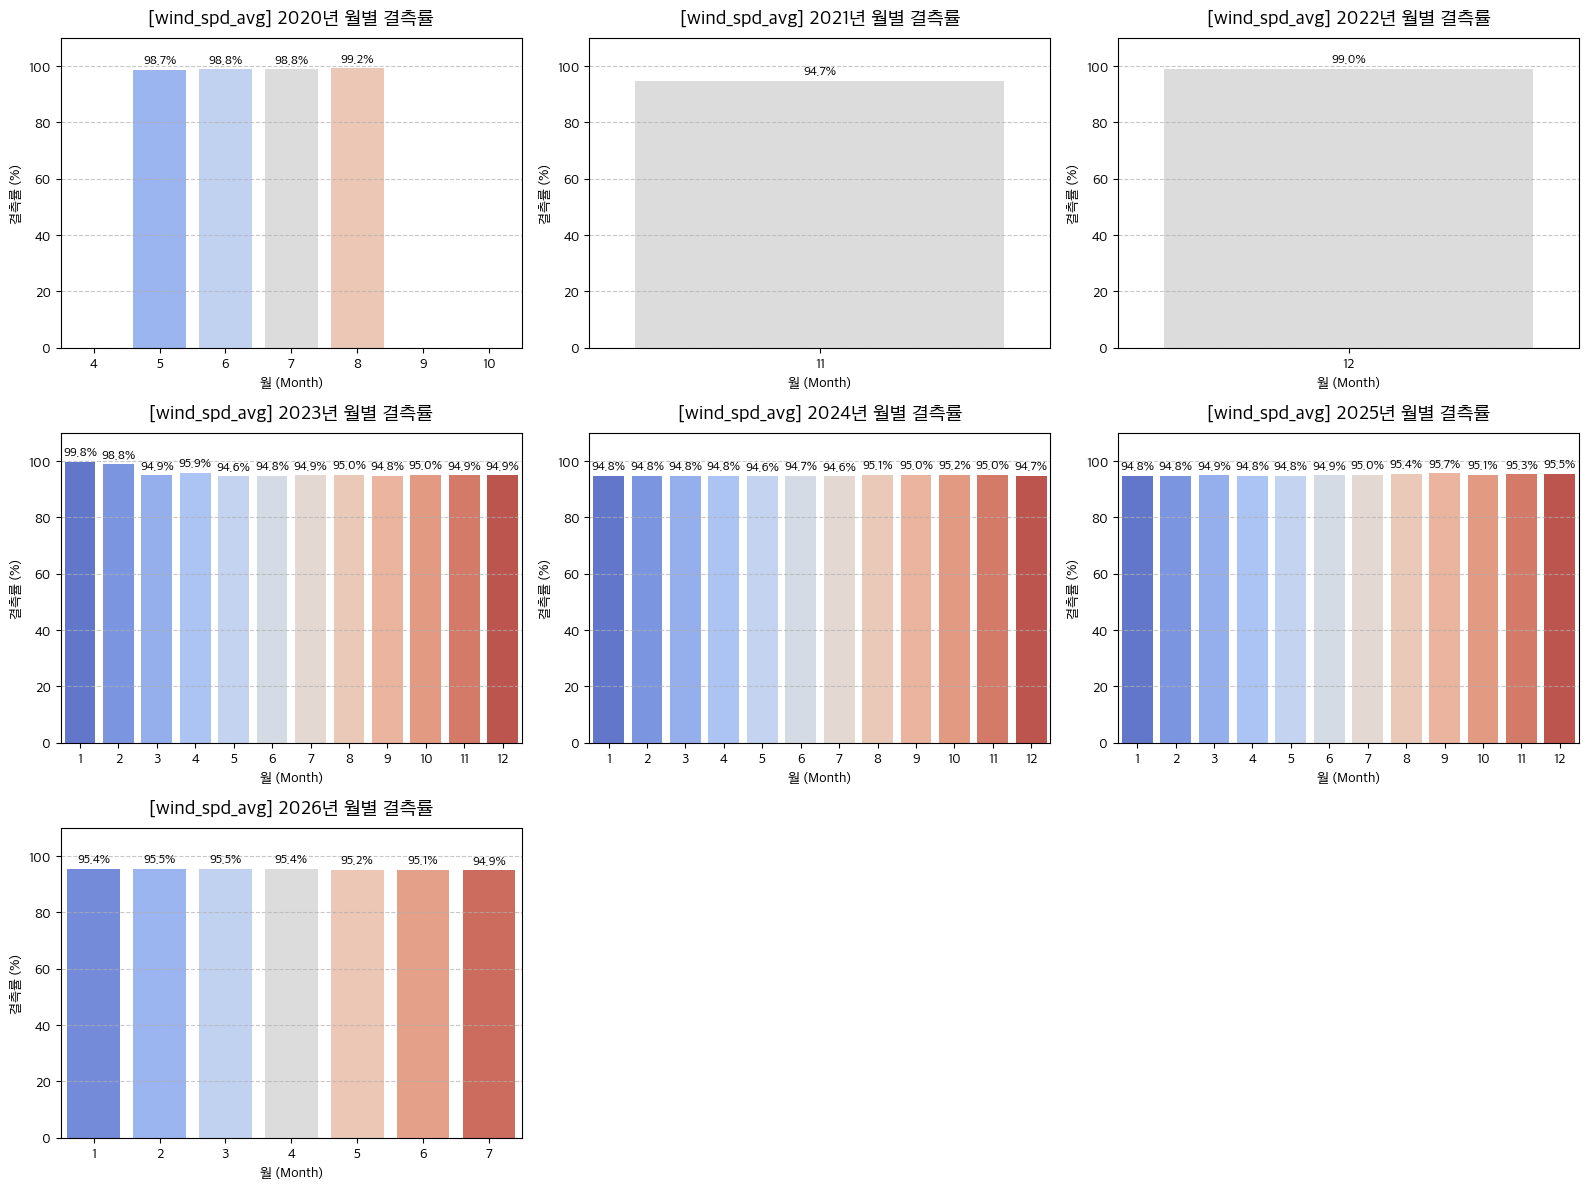

/var/folders/c6/_5q2k4291yj3lw8b4k_0fc8m0000gn/T/ipykernel_59808/1642909351.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=year_data, x='month', y=item_name, palette='coolwarm', ax=ax)
/var/folders/c6/_5q2k4291yj3lw8b4k_0fc8m0000gn/T/ipykernel_59808/1642909351.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=year_data, x='month', y=item_name, palette='coolwarm', ax=ax)
/var/folders/c6/_5q2k4291yj3lw8b4k_0fc8m0000gn/T/ipykernel_59808/1642909351.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=year_data, x='month',

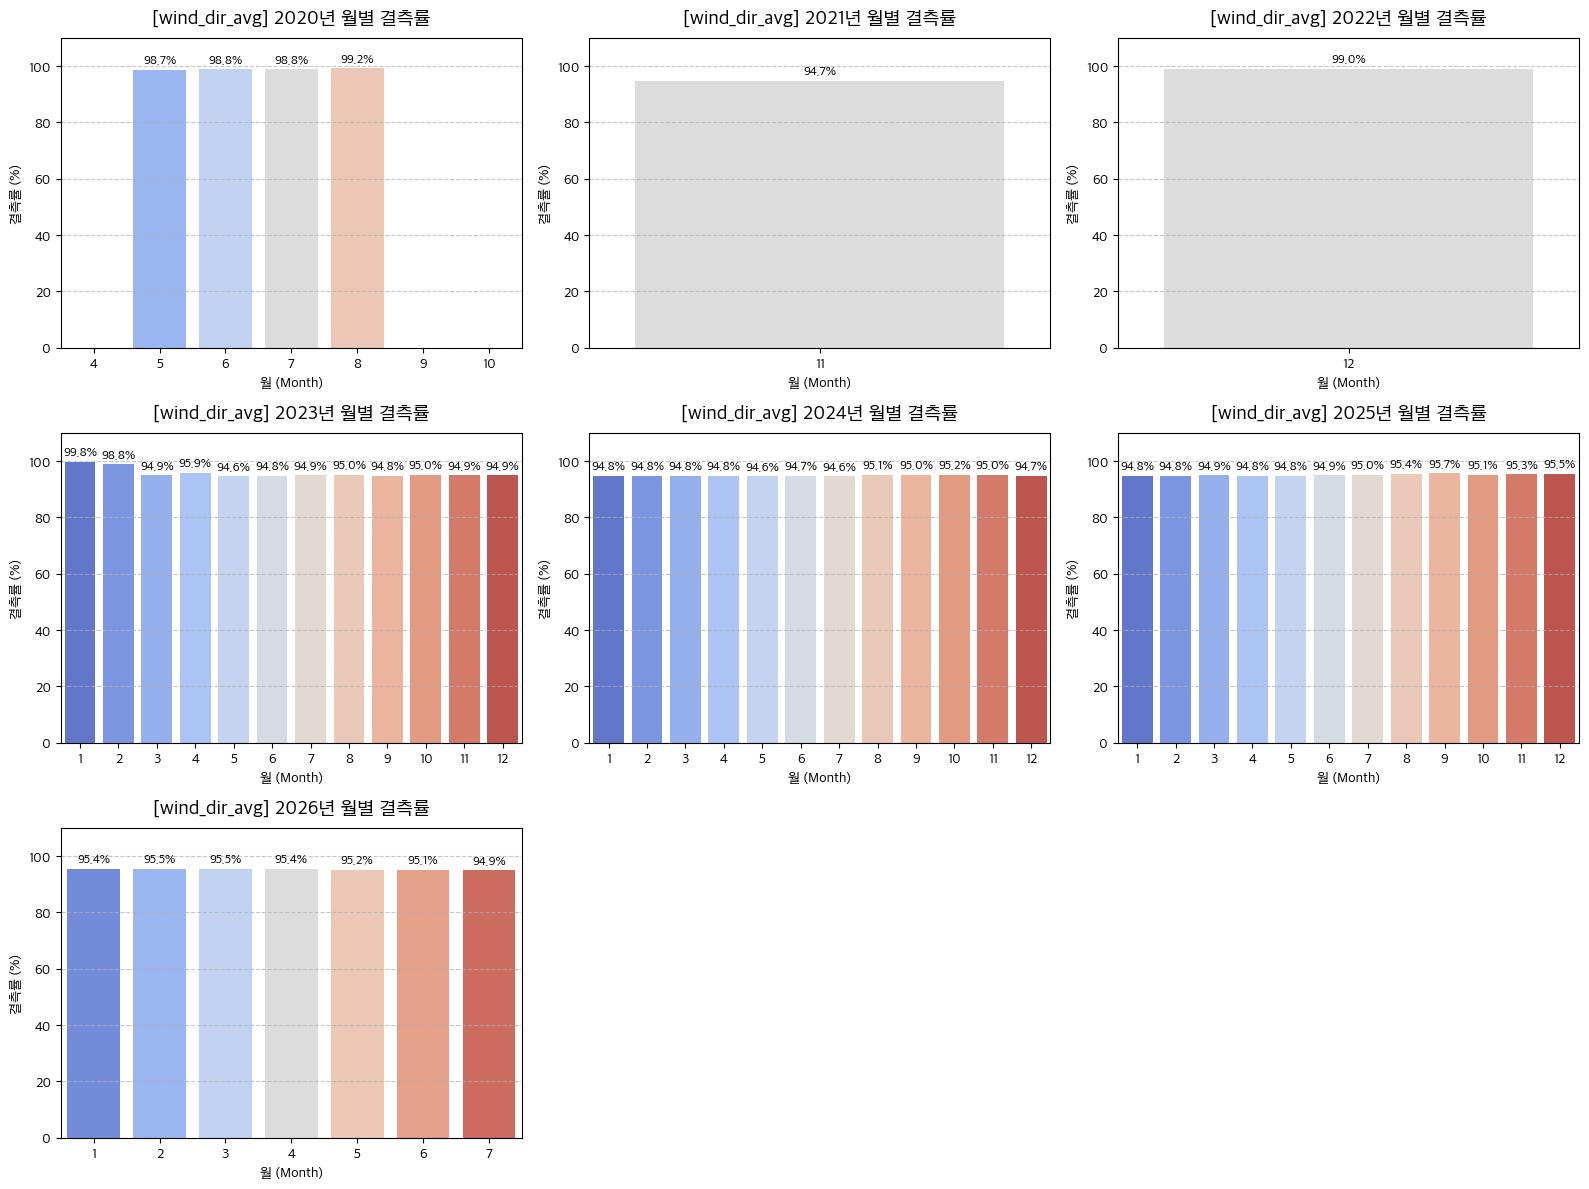

/var/folders/c6/_5q2k4291yj3lw8b4k_0fc8m0000gn/T/ipykernel_59808/1642909351.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=year_data, x='month', y=item_name, palette='coolwarm', ax=ax)
/var/folders/c6/_5q2k4291yj3lw8b4k_0fc8m0000gn/T/ipykernel_59808/1642909351.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=year_data, x='month', y=item_name, palette='coolwarm', ax=ax)
/var/folders/c6/_5q2k4291yj3lw8b4k_0fc8m0000gn/T/ipykernel_59808/1642909351.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=year_data, x='month',

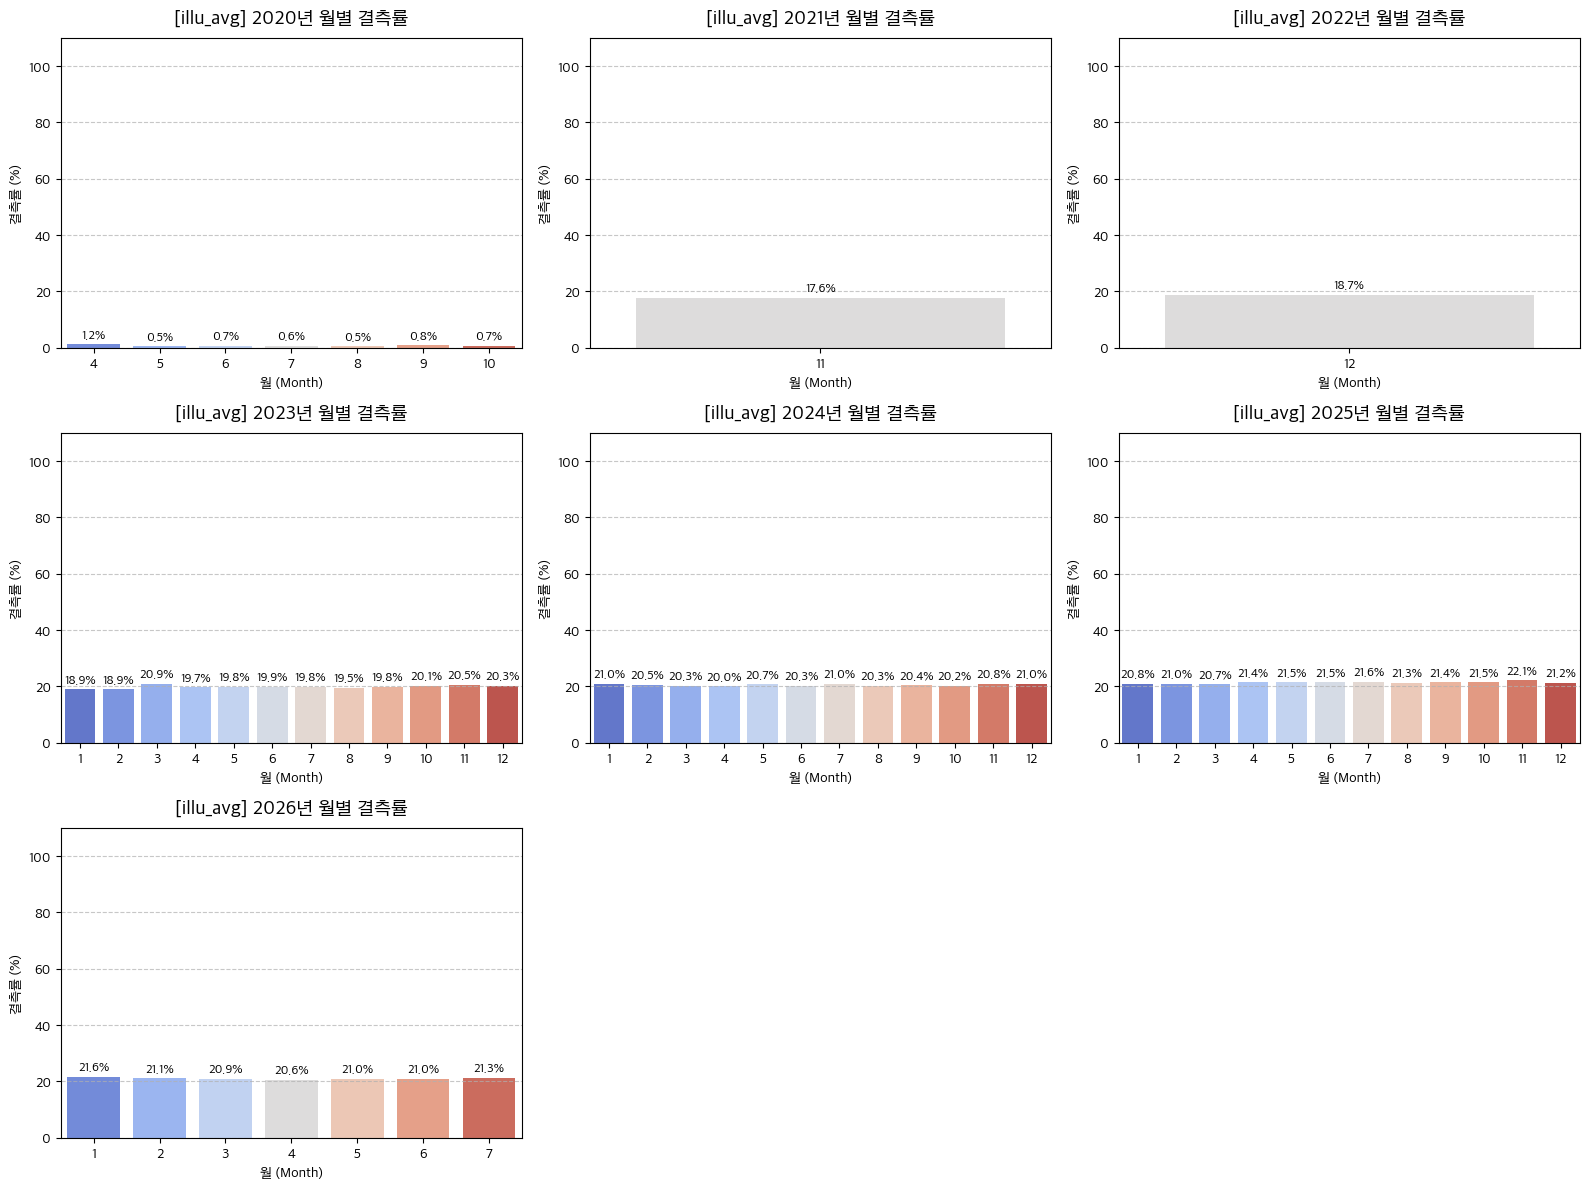

/var/folders/c6/_5q2k4291yj3lw8b4k_0fc8m0000gn/T/ipykernel_59808/1642909351.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=year_data, x='month', y=item_name, palette='coolwarm', ax=ax)
/var/folders/c6/_5q2k4291yj3lw8b4k_0fc8m0000gn/T/ipykernel_59808/1642909351.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=year_data, x='month', y=item_name, palette='coolwarm', ax=ax)
/var/folders/c6/_5q2k4291yj3lw8b4k_0fc8m0000gn/T/ipykernel_59808/1642909351.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=year_data, x='month',

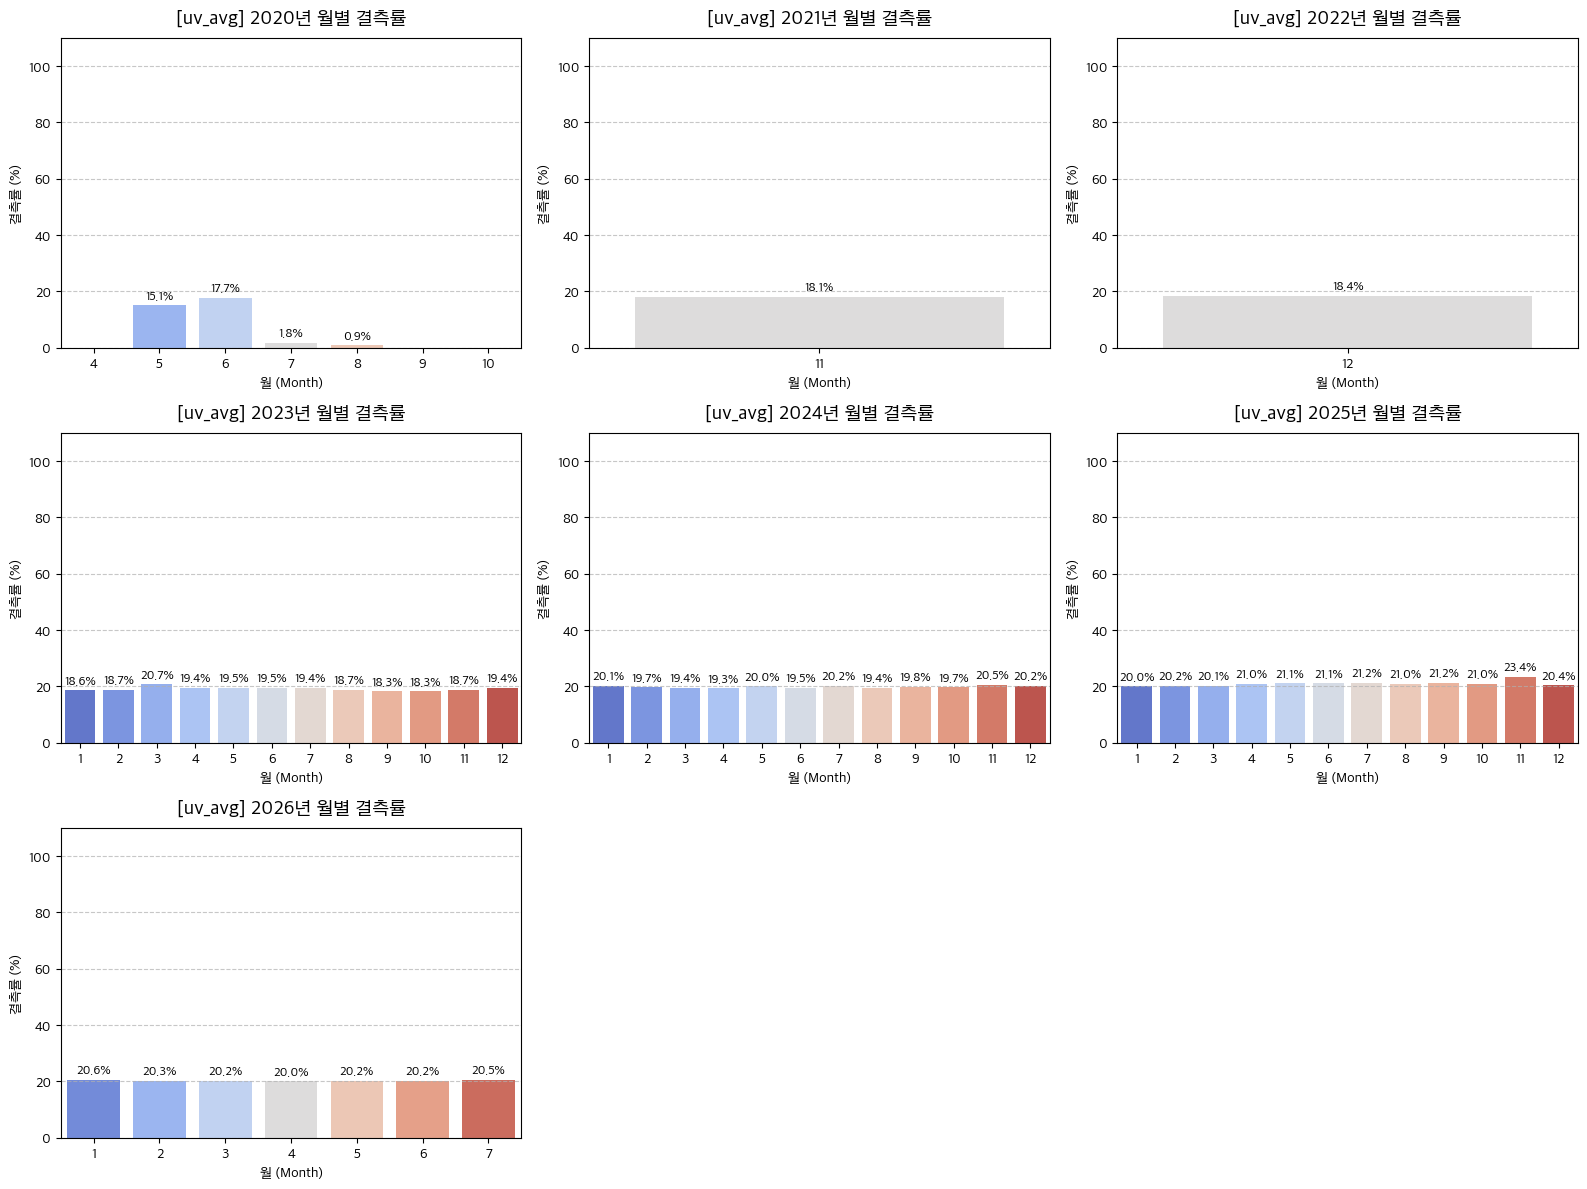

/var/folders/c6/_5q2k4291yj3lw8b4k_0fc8m0000gn/T/ipykernel_59808/1642909351.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=year_data, x='month', y=item_name, palette='coolwarm', ax=ax)
/var/folders/c6/_5q2k4291yj3lw8b4k_0fc8m0000gn/T/ipykernel_59808/1642909351.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=year_data, x='month', y=item_name, palette='coolwarm', ax=ax)
/var/folders/c6/_5q2k4291yj3lw8b4k_0fc8m0000gn/T/ipykernel_59808/1642909351.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=year_data, x='month',

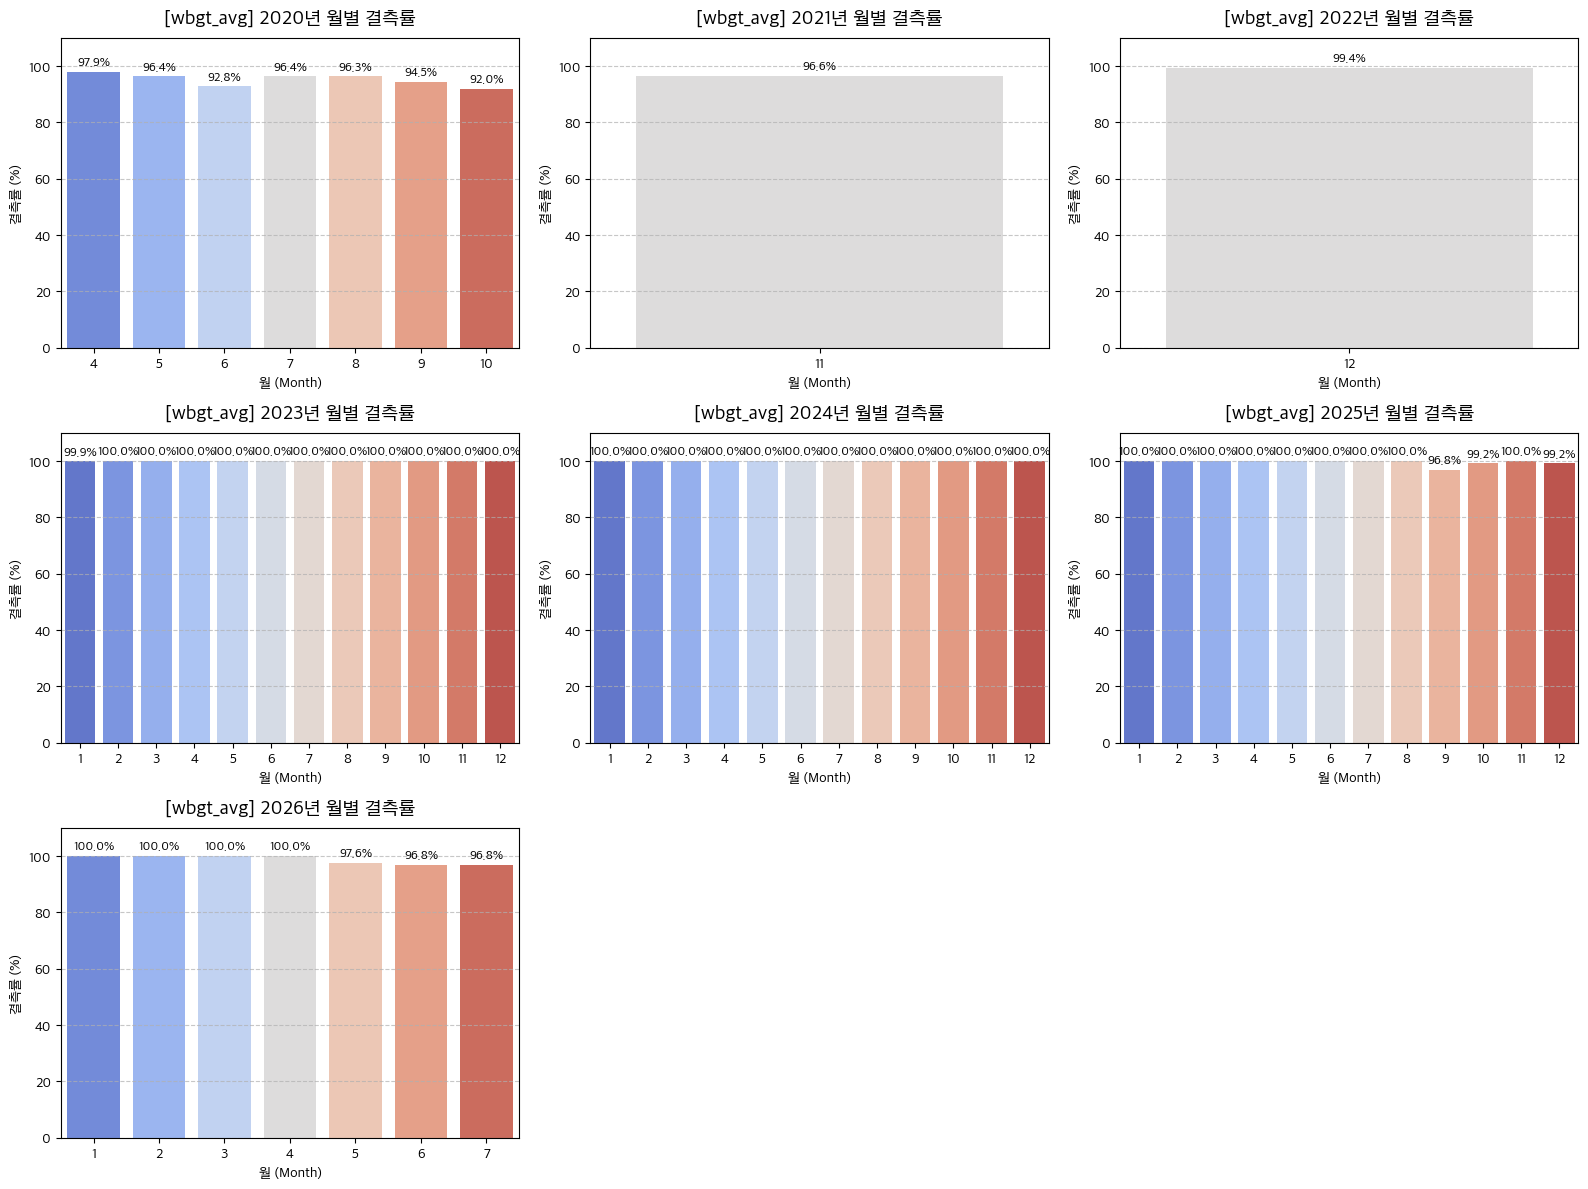

In [26]:
# --------------------------------------------------
# [1] 모든 기상 지표의 연도별/월별 결측률 통합 분석 및 시각화
# --------------------------------------------------
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

climate_cols = ['temp_avg','humi_avg', 'wind_spd_avg','wind_dir_avg', 'illu_avg', 'uv_avg', 'wbgt_avg']

# 1. 쿼리 생성: 모든 컬럼의 연-월별 결측률을 단일 쿼리로 계산
null_pct_sqls = [f"ROUND(SUM(CASE WHEN {col} IS NULL THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 1) AS {col}" for col in climate_cols]
null_pct_sql_str = ",\n        ".join(null_pct_sqls)

query_all_seasonal = f"""
    SELECT 
        EXTRACT(year FROM measure_timestamp) AS year,
        EXTRACT(month FROM measure_timestamp) AS month,
        {null_pct_sql_str}
    FROM v_sdot
    GROUP BY year, month
    ORDER BY year, month
"""
df_all_seasonal = duckdb.sql(query_all_seasonal).df()

# --------------------------------------------------
# [시각화 1] 전체 지표 결측률 타임라인 히트맵 (거시적 관점)
# --------------------------------------------------
# 'YYYY-MM' 형식의 파생 컬럼 생성
df_all_seasonal['year_month'] = df_all_seasonal['year'].astype(int).astype(str) + '-' + df_all_seasonal['month'].astype(int).astype(str).str.zfill(2)
df_heatmap = df_all_seasonal.set_index('year_month')[climate_cols].T

plt.figure(figsize=(22, 10))
sns.heatmap(df_heatmap, cmap='Reds', annot=False, cbar_kws={'label': '결측률 (%)'})
plt.title("전체 기상 지표의 연도-월별 결측률 흐름 (Heatmap)", fontsize=18, pad=15)
plt.xlabel("연도-월", fontsize=12)
plt.ylabel("측정 항목", fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# --------------------------------------------------
# [시각화 2] 지표별 연도/월별 3열 Grid 바 차트 (미시적 관점)
# --------------------------------------------------
years = sorted(df_all_seasonal['year'].dropna().unique())
cols = 3
rows = math.ceil(len(years) / cols)

def plot_seasonal_nulls_for_item(item_name):
    fig, axes = plt.subplots(nrows=rows, ncols=cols, figsize=(16, 4 * rows))
    axes = axes.flatten()
    
    for i, year in enumerate(years):
        ax = axes[i]
        year_data = df_all_seasonal[df_all_seasonal['year'] == year]
        
        sns.barplot(data=year_data, x='month', y=item_name, palette='coolwarm', ax=ax)
        
        ax.set_title(f"[{item_name}] {int(year)}년 월별 결측률", fontsize=14, pad=10)
        ax.set_xlabel("월 (Month)", fontsize=10)
        ax.set_ylabel("결측률 (%)", fontsize=10)
        ax.set_ylim(0, 110) # 텍스트 잘림 방지
        ax.grid(axis='y', linestyle='--', alpha=0.7)
        
        # 막대 위에 % 표시
        for p in ax.patches:
            height = p.get_height()
            if height > 0:
                ax.annotate(f"{height}%", 
                            (p.get_x() + p.get_width() / 2., height), 
                            ha='center', va='bottom', fontsize=9, color='black', 
                            xytext=(0, 4), textcoords='offset points')
                            
    # 데이터가 없는 남은 subplot 숨기기
    for j in range(len(years), len(axes)):
        fig.delaxes(axes[j])
        
    plt.tight_layout()
    plt.show()

# 21개 지표 모두에 대해 Grid 그래프 반복 출력
for col in climate_cols:
    plot_seasonal_nulls_for_item(col)

# [6] 기상 지표별 수집 누락(65분 이상 간격) 발생 비율 분석

In [27]:
query_missing_freq = f"""
    WITH unpivoted_data AS (
        UNPIVOT (
            SELECT 
                sensor_id_matched, 
                measure_timestamp, 
                {climate_cols_cast_str}
            FROM v_sdot
        )
        ON {climate_cols_str}
        INTO
            NAME measure_type
            VALUE measure_value
    ),
    gap_calc AS (
        SELECT 
            measure_type,
            DATE_DIFF('minute', 
                      LAG(measure_timestamp) OVER(PARTITION BY sensor_id_matched, measure_type ORDER BY measure_timestamp), 
                      measure_timestamp) AS time_gap_minutes
        FROM unpivoted_data
        WHERE measure_value IS NOT NULL
    )
    SELECT 
        measure_type AS 측정_항목,
        COUNT(*) AS 총_수집_횟수,
        SUM(CASE WHEN time_gap_minutes > 65 THEN 1 ELSE 0 END) AS 지연_및_누락_횟수,
        ROUND(SUM(CASE WHEN time_gap_minutes > 65 THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2) AS 누락_발생_비율_pct
    FROM gap_calc
    WHERE time_gap_minutes > 0  
    GROUP BY measure_type
    ORDER BY 누락_발생_비율_pct DESC
"""
df_missing_freq = duckdb.sql(query_missing_freq).pl().to_pandas()

print("📌 [기상 지표별 통신 단절 및 수집 누락 발생 비율]")
display(df_missing_freq)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

📌 [기상 지표별 통신 단절 및 수집 누락 발생 비율]


,측정_항목,총_수집_횟수,지연_및_누락_횟수,누락_발생_비율_pct
0,humi_max,22056712,1211533,5.49
1,humi_min,22371120,1211732,5.42
2,wind_spd_min,1228005,66494,5.41
3,wind_dir_min,1227997,66485,5.41
4,uv_min,20271421,1025208,5.06
5,illu_max,20287418,1025673,5.06
6,illu_min,20287494,1024985,5.05
7,uv_max,20444408,1027721,5.03
8,humi_avg,26247889,1316204,5.01
9,temp_min,23702475,1174647,4.96


# [7] 센서별 측정 타임라인 시각화

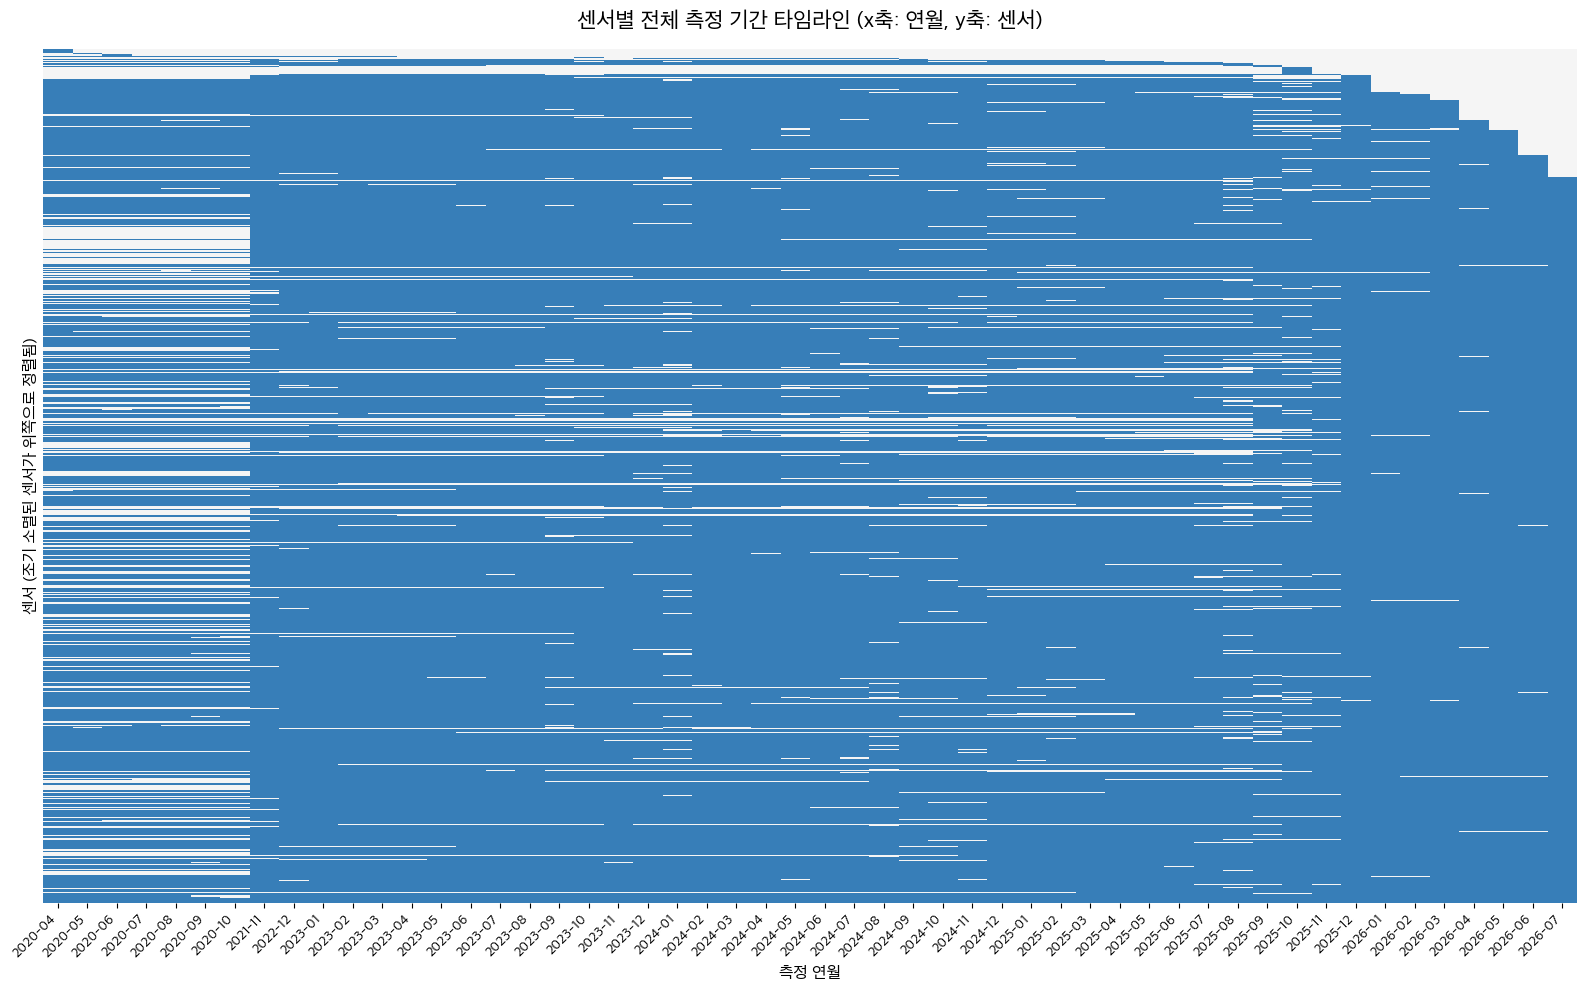

In [30]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 센서별, 연월(YYYY-MM)별 측정 이력 및 최종 측정일 집계
query_timeline = """
    WITH monthly_activity AS (
        SELECT 
            sensor_id_matched,
            STRFTIME(measure_timestamp, '%Y-%m') AS year_month,
            1 AS is_active
        FROM v_sdot
        GROUP BY sensor_id_matched, STRFTIME(measure_timestamp, '%Y-%m')
    ),
    last_measure AS (
        SELECT 
            sensor_id_matched,
            MAX(measure_timestamp) AS last_date
        FROM v_sdot
        GROUP BY sensor_id_matched
    )
    SELECT 
        m.sensor_id_matched,
        m.year_month,
        l.last_date,
        m.is_active
    FROM monthly_activity m
    JOIN last_measure l ON m.sensor_id_matched = l.sensor_id_matched
"""
df_timeline = duckdb.sql(query_timeline).df()

# 2. 히트맵을 위한 피벗 테이블 생성 (행: 센서, 열: 연월, 값: 1 또는 NaN)
df_pivot = df_timeline.pivot(index='sensor_id_matched', columns='year_month', values='is_active')

# 3. 조기 소멸된 센서가 위쪽으로 정렬되도록 인덱스 재정렬
# (Seaborn 히트맵은 데이터프레임의 첫 행을 맨 위에 출력하므로, last_date 오름차순 정렬)
sensor_order = df_timeline[['sensor_id_matched', 'last_date']].drop_duplicates().sort_values('last_date')['sensor_id_matched']
df_pivot = df_pivot.reindex(sensor_order)

# 4. 시각화
plt.figure(figsize=(16, 10))

# 0은 밝은 회색(결측), 1은 파란색(수집)으로 컬러맵 설정
cmap = sns.color_palette(["#f5f5f5", "#377eb8"]) 

# 결측치(NaN)를 0으로 채운 후 히트맵 생성
ax = sns.heatmap(df_pivot.fillna(0), cmap=cmap, cbar=False, yticklabels=False)

plt.title("센서별 전체 측정 기간 타임라인 (x축: 연월, y축: 센서)", fontsize=16, pad=15)
plt.xlabel("측정 연월", fontsize=12)
plt.ylabel("센서 (조기 소멸된 센서가 위쪽으로 정렬됨)", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [32]:
# --------------------------------------------------
# [2] 전체 데이터의 마지막 날짜 이전에 기록이 중단된 센서 확인
# --------------------------------------------------
import duckdb

# 1. 전체 센서 개수 확인
query_total_sensors = "SELECT COUNT(DISTINCT sensor_id_matched) FROM v_sdot"
total_count = duckdb.sql(query_total_sensors).fetchone()[0]

# 2. 임의의 기준일 없이, 전체 데이터의 MAX 날짜보다 먼저 기록이 끊긴 센서 조회
query_dead_sensors = """
    WITH GlobalMax AS (
        -- 전체 데이터베이스에서 가장 마지막에 수집된 날짜(예: 2026-07-19)를 자동으로 찾음
        SELECT MAX(DATE(measure_timestamp)) AS max_date 
        FROM v_sdot
    )
    SELECT 
        sensor_id_matched AS 센서_ID,
        MIN(measure_timestamp) AS 최초_측정일,
        MAX(measure_timestamp) AS 최종_측정일,
        DATE_DIFF('day', MIN(measure_timestamp), MAX(measure_timestamp)) AS 가동_기간_일수
    FROM v_sdot
    GROUP BY sensor_id_matched
    -- 센서별 마지막 측정일이 전체 데이터의 마지막 측정일보다 작은(이전인) 경우만 필터링
    HAVING MAX(DATE(measure_timestamp)) < (SELECT max_date FROM GlobalMax)
    ORDER BY 최종_측정일 ASC
"""
df_dead_sensors = duckdb.sql(query_dead_sensors).df()

dead_count = len(df_dead_sensors)
dead_ratio = (dead_count / total_count) * 100

print(f"📊 전체 센서 개수: {total_count}개")
print(f"🚨 마지막 수집일 이전에 기록을 중단한 센서 개수: {dead_count}개")
print(f"   -> 전체 대비 비율: {dead_ratio:.1f}%")
print("-" * 50)
print("📌 [기록 중단 센서 목록 일부 확인]")
display(df_dead_sensors.head(15))

📊 전체 센서 개수: 1187개
🚨 마지막 수집일 이전에 기록을 중단한 센서 개수: 249개
   -> 전체 대비 비율: 21.0%
--------------------------------------------------
📌 [기록 중단 센서 목록 일부 확인]


,센서_ID,최초_측정일,최종_측정일,가동_기간_일수
0,V02Q1940922,2020-04-02 17:00:00,2020-04-02 17:00:00,0
1,V02Q1940963,2020-04-02 15:00:00,2020-04-03 11:00:00,1
2,V02Q1940933,2020-04-03 16:00:00,2020-04-03 16:00:00,0
3,V02Q1940982,2020-04-01 01:00:00,2020-04-03 17:00:00,2
4,V02Q1940921,2020-04-16 13:00:00,2020-04-16 13:00:00,0
5,OT2CL200002,2020-05-06 10:35:00,2020-05-06 10:35:00,0
6,V02Q1950001,2020-05-13 14:45:00,2020-05-14 08:46:00,1
7,V02Q1940936,2020-06-10 14:19:00,2020-06-10 14:19:00,0
8,OT3CL180000,2020-06-22 16:34:00,2020-06-23 10:35:00,1
9,V02Q1940200,2020-04-01 01:00:00,2021-11-14 23:00:00,592


# [8] 지표별 전체 기간 결측 발생 분포

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

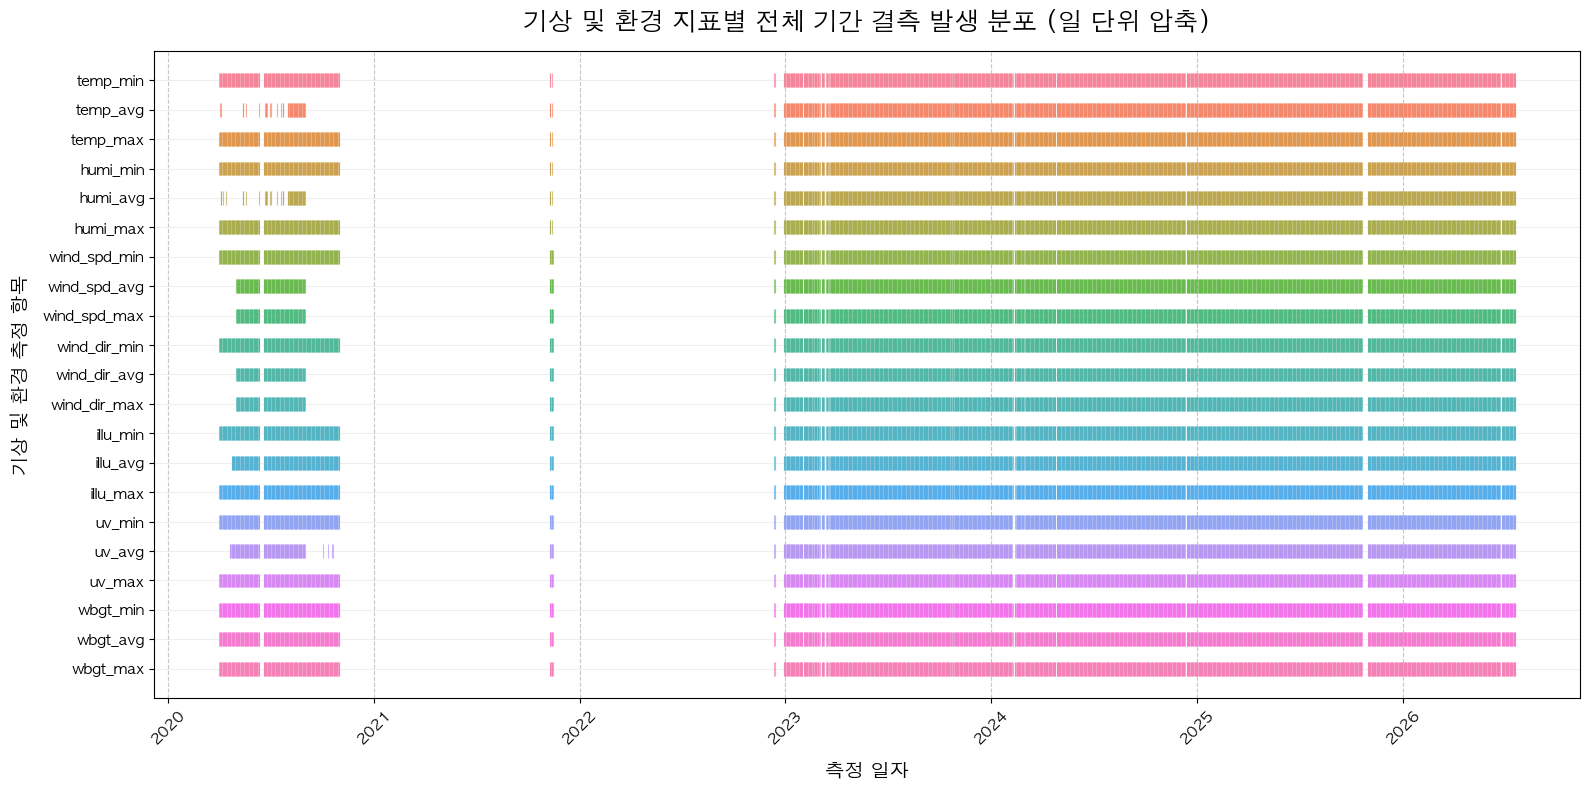

In [33]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 폰트 설정
# plt.rc('font', family='Malgun Gothic') # Windows
plt.rc('font', family='AppleGothic') # Mac
plt.rcParams['axes.unicode_minus'] = False

climate_cols = ['temp_min','temp_avg', 'temp_max',
                'humi_min','humi_avg', 'humi_max',
                'wind_spd_min','wind_spd_avg', 'wind_spd_max',
                'wind_dir_min','wind_dir_avg', 'wind_dir_max',
                'illu_min','illu_avg', 'illu_max',
                'uv_min','uv_avg', 'uv_max',
                'wbgt_min','wbgt_avg', 'wbgt_max']

# --------------------------------------------------
# 1. 초경량화 데이터 추출: DISTINCT DATE() 활용
# --------------------------------------------------
# 수백만 건의 원본 데이터 대신, "결측이 발생한 날짜"만 중복 없이 가져옵니다.
# 아무리 데이터가 많아도 (전체 일수 x 20개 지표) 건수 이상을 넘지 않아 매우 가볍습니다.
queries = []
for col in climate_cols:
    q = f"""
        SELECT DISTINCT DATE(measure_timestamp) AS measure_date, '{col}' AS indicator 
        FROM v_sdot 
        WHERE {col} IS NULL
    """
    queries.append(q)

query_lightweight = " UNION ALL ".join(queries)

# 쿼리 실행 (순식간에 끝납니다!)
df_missing_scatter = duckdb.sql(query_lightweight).df()
df_missing_scatter['measure_date'] = pd.to_datetime(df_missing_scatter['measure_date'])

# --------------------------------------------------
# 2. 산점도(Scatter Plot) 시각화
# --------------------------------------------------
plt.figure(figsize=(16, 8))

if df_missing_scatter.empty:
    print("🚨 결측 데이터가 없습니다.")
else:
    # y축 정렬
    order_list = list(reversed(climate_cols))
    
    sns.scatterplot(
        data=df_missing_scatter, 
        x='measure_date', 
        y='indicator', 
        hue='indicator',   
        marker='|',        
        s=100,             # 일 단위이므로 마커 크기를 키워 연속성을 강조
        alpha=0.6,         
        legend=False       
    )

    plt.title('기상 및 환경 지표별 전체 기간 결측 발생 분포 (일 단위 압축)', fontsize=18, fontweight='bold', pad=15)
    plt.xlabel('측정 일자', fontsize=14, labelpad=10)
    plt.ylabel('기상 및 환경 측정 항목', fontsize=14, labelpad=10)

    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.grid(axis='y', linestyle='-', alpha=0.2)

    plt.yticks(fontsize=11)
    plt.xticks(fontsize=11, rotation=45)

    plt.tight_layout()
    plt.show()